# Running OpenCLIP models using OpenVINO™

[OpenCLIP](https://github.com/mlfoundations/open_clip) is an open source implementation of OpenAI's [CLIP](https://arxiv.org/abs/2103.00020) (Contrastive Language-Image Pre-training).

CLIP (Contrastive Language-Image Pre-Training) is a neural network trained on various (image, text) pairs. It can be instructed in natural language to predict the most relevant text snippet, given an image, without directly optimizing for the task.
CLIP uses a [ViT](https://arxiv.org/abs/2010.11929) like transformer to get visual features and a causal language model to get the text features. The text and visual features are then projected into a latent space with identical dimensions. The dot product between the projected image and text features is then used as a similarity score.

![clip](https://raw.githubusercontent.com/openai/CLIP/main/CLIP.png)

[**image_source*](https://github.com/openai/CLIP/blob/main/README.md)

You can find more information about this model in the [research paper](https://arxiv.org/abs/2103.00020) and GitHub [repository](https://github.com/mlfoundations/open_clip).


OpenCLIP could be used for calculation the similarity between arbitrary image, text inputs and perform zero-shot image classifications. 
In this tutorial, we will use the [OpenCLIP](https://github.com/mlfoundations/open_clip) model to try out the different tasks it is intended for. Additionally, the notebook demonstrates how to optimize the model using [NNCF](https://github.com/openvinotoolkit/nncf/).

The notebook contains the following steps:

1. Download the model.
2. Instantiate the PyTorch model.
3. Convert model to OpenVINO IR, using the model conversion API.
4. Run inference with OpenVINO.
5. Quantize the converted model with NNCF.
6. Check the quantized model inference result.
7. Compare model size of converted and quantized models.
8. Compare performance of converted and quantized models.
9. Launch interactive demo


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).


#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Run PyTorch model inference](#Run-PyTorch-model-inference)
    - [Prepare data](#Prepare-data)
    - [Prepare model and perform inference](#Prepare-model-and-perform-inference)
- [Run OpenVINO model](#Run-OpenVINO-model)
    - [Select inference device](#Select-inference-device)
- [Load and convert model using Optimum Intel](#Load-and-convert-model-using-Optimum-Intel)
- [Perform text similarity task](#Perform-text-similarity-task)
- [Perform image similarity task](#Perform-image-similarity-task)
- [Perform zero-short image classification](#Perform-zero-short-image-classification)
- [Quantize model to INT8 using NNCF](#Quantize-model-to-INT8-using-NNCF)
    - [Prepare datasets](#Prepare-datasets)
    - [Perform quantization for text model](#Perform-quantization-for-text-model)
    - [Perform quantization for vision model](#Perform-quantization-for-vision-model)
    - [Perform visual content search](#Perform-visual-content-search)
    - [Run quantized OpenVINO model](#Run-quantized-OpenVINO-model)
    - [Compare File Size](#Compare-File-Size)
    - [Compare inference time of the FP16 IR and quantized models](#Compare-inference-time-of-the-FP16-IR-and-quantized-models)
- [Interactive demo](#Interactive-demo)

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/open-clip/open-clip.ipynb" />

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install required dependencies

In [ ]:
%pip install -q --extra-index-url https://download.pytorch.org/whl/cpu "gradio>=4.19" "matplotlib>=3.4" "openvino>=2025.0.0" "transformers[torch]>=4.30" "datasets" "nncf>=2.6.0" "torch>=2.1" "open_clip_torch" "git+https://github.com/huggingface/optimum-intel.git"\
"nncf==2.14.1" "numpy<2.0" Pillow

from pathlib import Path
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("open-clip.ipynb")

## Run PyTorch model inference
[back to top ⬆️](#Table-of-contents:)

We will use pretrained model [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). It's a CLIP [ViT-B/32](https://arxiv.org/abs/2010.11929) model trained with the LAION-2B English subset of [LAION-5B](https://laion.ai/blog/laion-5b/) using [OpenCLIP](https://github.com/mlfoundations/open_clip). More OpenCLIP models could be found [here](https://huggingface.co/models?library=open_clip&p=1&sort=trending). More information, about supported models (e.g. number of parameters), also presented [in this table](https://github.com/mlfoundations/open_clip/blob/main/docs/model_profile.csv).

Let's try zero-shot image classification task. Zero-shot image classification is a computer vision task to classify images into one of several classes without any prior training or knowledge of the classes.

![zero-shot-pipeline](https://user-images.githubusercontent.com/29454499/207773481-d77cacf8-6cdc-4765-a31b-a1669476d620.png)

[**image source*](https://huggingface.co/tasks/zero-shot-image-classification)

Zero-shot learning resolves several challenges in image retrieval systems. For example, with the rapid growth of categories on the web, it is challenging to index images based on unseen categories. We can associate unseen categories to images with zero-shot learning by exploiting attributes to model's relationship between visual features and labels.

### Prepare data
[back to top ⬆️](#Table-of-contents:)


To perform classification, define labels and load an image in RGB format. To give the model wider text context and improve guidance, we extend the labels description using the template "This is a photo of a".
Both the list of label descriptions and image should be passed through the processor to obtain a dictionary with input data in the model-specific format. The model predicts an image-text similarity score in raw logits format, which can be normalized to the `[0, 1]` range using the `softmax` function. Then, we select labels with the highest similarity score for the final result.

In [2]:
import requests
from PIL import Image

sample_path = Path("data/coco.jpg")
sample_path.parent.mkdir(parents=True, exist_ok=True)

if not sample_path.exists():
    r = requests.get("https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco.jpg")

    with sample_path.open("wb") as f:
        f.write(r.content)

image = Image.open(sample_path)

input_labels = [
    "cat",
    "dog",
    "wolf",
    "tiger",
    "man",
    "horse",
    "frog",
    "tree",
    "house",
    "computer",
]
text_descriptions = [f"This is a photo of a {label}" for label in input_labels]

In [3]:
from typing import List
import matplotlib.pyplot as plt
import numpy as np


def visualize_result(image: Image, labels: List[str], probs: np.ndarray, top: int = 5):
    """
    Utility function for visualization classification results
    params:
      image: input image
      labels: list of classification labels
      probs: model predicted softmaxed probabilities for each label
      top: number of the highest probability results for visualization
    returns:
      None
    """
    plt.figure(figsize=(64, 64))
    top_labels = np.argsort(-probs)[: min(top, probs.shape[0])]
    top_probs = probs[top_labels]
    plt.subplot(8, 8, 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(8, 8, 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs)
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.yticks(y, [labels[index] for index in top_labels])
    plt.xlabel("probability")

### Prepare model and perform inference
[back to top ⬆️](#Table-of-contents:)


At first, we need to load model and preprocess via calling `create_model_and_transforms()` method of open_clip module. Also we need to load tokenizer with `get_tokenizer()` method. After that we will prepare image embeddings via calling `preprocess()` and tokenized inputs via calling `tokenizer()`. Then we will evoke `encode_image()` for image embeddings and `encode_text()` for text embeddings to get image and text features. And finally, we will calculate probabilities via `sofrmax` function.

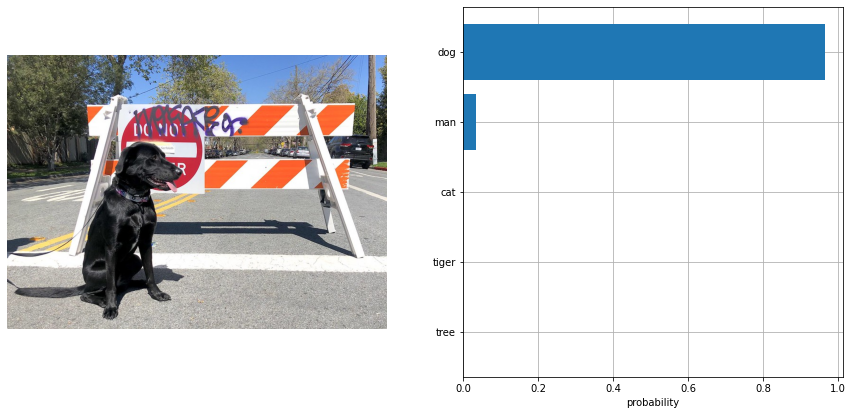

In [4]:
import torch
from PIL import Image
import open_clip

model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
model.eval().to("cpu")  # model in train mode by default, impacts some models with BatchNorm or stochastic depth active
tokenizer = open_clip.get_tokenizer("ViT-B-32")

image = Image.open("./data/coco.jpg")
processed_image = preprocess(image).unsqueeze(0)
text = tokenizer(input_labels)

image_features = model.encode_image(processed_image)
text_features = model.encode_text(text)
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)

text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
visualize_result(image, input_labels, text_probs.detach().numpy()[0])

## Run OpenVINO model
[back to top ⬆️](#Table-of-contents:)

The steps for making predictions with the OpenVINO CLIP model are similar to the PyTorch model. Let us check the model result using the same input data from the example above with PyTorch.

In [5]:
import openvino as ov

# create OpenVINO core object instance
core = ov.Core()

### Select inference device
[back to top ⬆️](#Table-of-contents:)

select device from dropdown list for running inference using OpenVINO

In [ ]:
from notebook_utils import device_widget

device = device_widget()

device

## Load and convert model using Optimum Intel
[back to top ⬆️](#Table-of-contents:)



Optimum Intel can be used to load optimized models from the [Hugging Face Hub](https://huggingface.co/docs/optimum/intel/hf.co/models) and create pipelines to run an inference with OpenVINO Runtime using Hugging Face APIs. The Optimum Inference models are API are presented several classes to work with OpenCLIP models: `OVModelOpenCLIPVisual` for work with visual model, `OVModelOpenCLIPText` for work with text model and `OVModelOpenCLIPForZeroShotImageClassification` to work with one model object and perform Zero-Shot Image Classification task.

Model class initialization starts with calling `from_pretrained` method. When downloading and converting Transformers model, the parameter `export=True` should be added (as we already converted model before, we do not need to provide this parameter). We can save the converted model for the next usage with the `save_pretrained` method.
Tokenizer class and pipelines API are compatible with Optimum models.

In [ ]:
from optimum.intel import OVModelOpenCLIPText, OVModelOpenCLIPVisual
from transformers import AutoProcessor, AutoTokenizer

model_id = "laion/CLIP-ViT-B-32-laion2B-s34B-b79K"
model_dir = Path("CLIP-ViT-B-32-laion2B-s34B-b79K")

visual_model = OVModelOpenCLIPVisual.from_pretrained(model_id, export=True, trust_remote_code=True)
visual_model.save_pretrained(model_dir)
text_model = OVModelOpenCLIPText.from_pretrained(model_id, export=True, trust_remote_code=True)
text_model.save_pretrained(model_dir)
ov_tokenizer = AutoTokenizer.from_pretrained(model_id, export=True, trust_remote_code=True)
ov_tokenizer.save_pretrained(model_dir)
ov_processor = AutoProcessor.from_pretrained(model_id, export=True, trust_remote_code=True)
ov_processor.save_pretrained(model_dir)

## Perform text similarity task
[back to top ⬆️](#Table-of-contents:)

In [8]:
from torch.nn import CosineSimilarity

cossim = CosineSimilarity(dim=0, eps=1e-6)

ov_tokenizer.pad_token_id = 0
text1 = ov_tokenizer(
    text=["I like cats. They are adorable."], padding="max_length", max_length=ov_tokenizer.model_max_length, truncation=True, return_tensors="pt"
)
text_features1 = text_model(text1["input_ids"])[0]

text2 = ov_tokenizer(
    text=["I like dogs. They are gorgeous."], padding="max_length", max_length=ov_tokenizer.model_max_length, truncation=True, return_tensors="pt"
)
text_features2 = text_model(text2["input_ids"])[0]

text_probs = cossim(text_features1[0], text_features2[0])

print(
    f"Texts are similar on {text_probs * 100:0.2f}%",
)

Texts are similar on 80.21%


## Perform image similarity task
[back to top ⬆️](#Table-of-contents:)

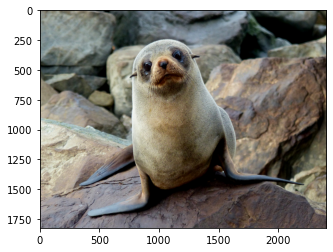

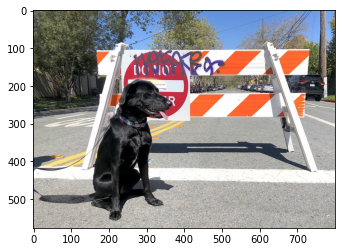

Furseal and Coco images are similar on 35.69%


In [9]:
sample_furseal_path = Path("data/furseal.jpg")

if not sample_furseal_path.exists():
    r = requests.get("https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/3f779fc1-c1b2-4dec-915a-64dae510a2bb")

    with sample_furseal_path.open("wb") as f:
        f.write(r.content)

furseal_image = Image.open(sample_furseal_path)
coco_image = Image.open(sample_path)

furseal_data = ov_processor(images=furseal_image)["pixel_values"]
coco_data = ov_processor(images=coco_image)["pixel_values"]
furseal_image_features = visual_model(furseal_data)[0]
coco_image_features = visual_model(coco_data)[0]

plt.imshow(furseal_image)
plt.show()

plt.imshow(coco_image)
plt.show()

img_probs = cossim(furseal_image_features[0], coco_image_features[0])
print(
    f"Furseal and Coco images are similar on {img_probs * 100:0.2f}%",
)

## Perform zero-short image classification
[back to top ⬆️](#Table-of-contents:)

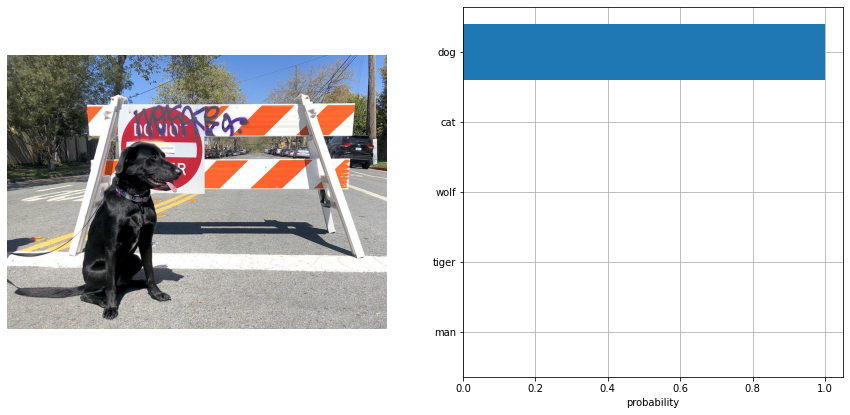

In [10]:
text = ov_tokenizer(text=text_descriptions, padding="max_length", max_length=ov_tokenizer.model_max_length, truncation=True, return_tensors="pt")
text_features = text_model(text["input_ids"])[0]

img_data = ov_processor(images=coco_image)["pixel_values"]
image_features = visual_model(img_data)[0]

text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
visualize_result(coco_image, input_labels, text_probs.detach().numpy()[0])

## Perform visual content search
[back to top ⬆️](#Table-of-contents:)

Semantic visual content search is a machine learning task that uses either a text query or an input image to search a database of images (photo gallery, video) to find images that are semantically similar to the search query. To explore more about that task and ways of execution it using OpenVINO, you can check out the notebook [Visual Content Search using MobileCLIP and OpenVINO™](https://github.com/openvinotoolkit/openvino_notebooks/tree/latest/notebooks/mobileclip-video-search).

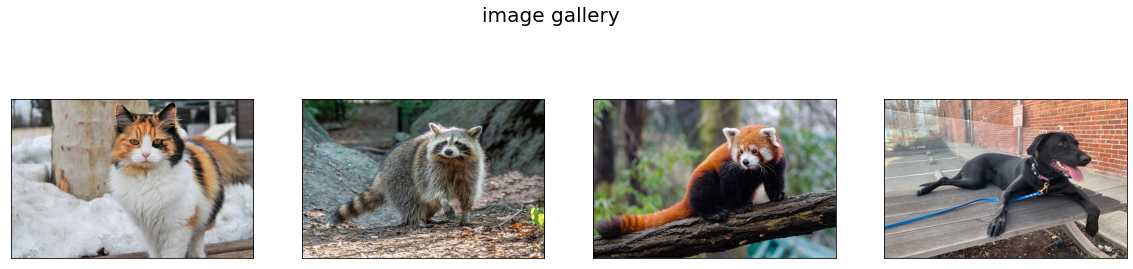

In [11]:
from notebook_utils import download_file


def visualize_images(images: List, query: str = "", selected: List[int] = None):
    """
    Utility function for visualization classification results
    params:
      images (List[Image]) - list of images for visualization
      query (str) - title for visualization
      selected (List[int]) - list of selected image indices from images
    returns:
      matplotlib.Figure
    """
    figsize = (20, 5)
    fig, axs = plt.subplots(1, 4, figsize=figsize, sharex="all", sharey="all")
    fig.patch.set_facecolor("white")
    list_axes = list(axs.flat)
    if query:
        fig.suptitle(query, fontsize=20)
    for idx, a in enumerate(list_axes):
        a.set_xticklabels([])
        a.set_yticklabels([])
        a.get_xaxis().set_visible(False)
        a.get_yaxis().set_visible(False)
        a.grid(False)
        a.imshow(images[idx])
        if selected is not None and idx not in selected:
            mask = np.ones_like(np.array(images[idx]))
            a.imshow(mask, "jet", interpolation="none", alpha=0.75)


images_urls = [
    "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/9bb40168-82b5-4b11-ada6-d8df104c736c",
    "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/0747b6db-12c3-4252-9a6a-057dcf8f3d4e",
    "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/282ce53e-912d-41aa-ab48-2a001c022d74",
    "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bricks.png",
]
image_names = ["cat.png", "raccoon.png", "red_panda.png", "dog.png"]
sample_path = Path("data")
sample_path.mkdir(parents=True, exist_ok=True)

images = []
for image_name, image_url in zip(image_names, images_urls):
    image_path = sample_path / image_name
    if not image_path.exists():
        download_file(image_url, filename=image_name, directory=sample_path)
    images.append(Image.open(image_path).convert("RGB").resize((640, 420)))

input_labels_content_search = ["red panda"]
text_descriptions_content_search = [f"This is a photo of a {label}" for label in input_labels_content_search]

visualize_images(images, "image gallery")

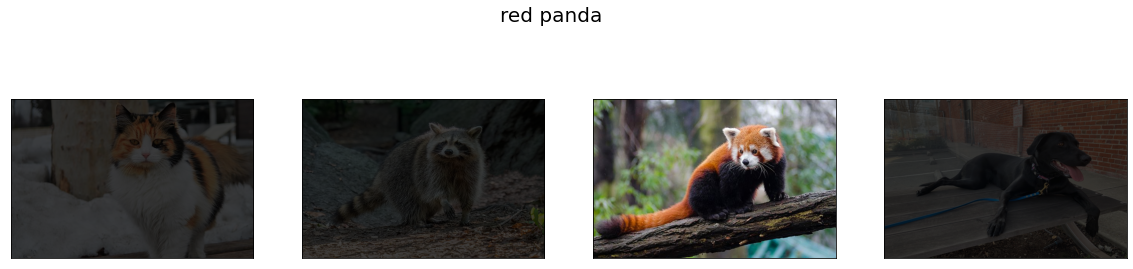

In [12]:
text = ov_tokenizer(text=text_descriptions_content_search, padding="max_length", max_length=ov_tokenizer.model_max_length, truncation=True, return_tensors="pt")
text_features = text_model(text["input_ids"])[0]

img_data = ov_processor(images=images)["pixel_values"]
image_features = visual_model(img_data)[0]

text_probs = (100.0 * text_features @ image_features.T).softmax(dim=-1)
selected_image = [torch.argmax(text_probs[0]).item()]

visualize_images(images, input_labels_content_search[0], selected_image)

## Quantize model to INT8 using NNCF
[back to top ⬆️](#Table-of-contents:)

The goal of this part of tutorial is to demonstrate how to speed up the model by applying 8-bit post-training quantization from [NNCF](https://github.com/openvinotoolkit/nncf/) (Neural Network Compression Framework) and infer quantized model via OpenVINO™ Toolkit. 
[NNCF](https://github.com/openvinotoolkit/nncf/) enables post-training quantization by adding quantization layers into model graph and then using a subset of the training dataset to initialize the parameters of these additional quantization layers. Quantized operations are executed in `INT8` instead of `FP32`/`FP16` making model inference faster.
The optimization process contains the following steps:

1. Prepare quantization dataset
2. Quantize the converted OpenVINO model with NNCF.
3. Check the model result using the same input data like we use.
4. Compare model size of converted and quantized models.
5. Compare performance of converted and quantized models.

> **Note:** quantization process may require additional time and memory for performing. You can disable it using widget below:

In [ ]:
from notebook_utils import quantization_widget

to_quantize = quantization_widget()

to_quantize

In [14]:
# Fetch skip_kernel_extension module
if not Path("skip_kernel_extension.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
    )
    open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

### Prepare datasets
[back to top ⬆️](#Table-of-contents:)

The [Conceptual Captions](https://ai.google.com/research/ConceptualCaptions/) dataset consisting of ~3.3M images annotated with captions is used to quantize model.

In [15]:
%%skip not $to_quantize.value

import requests
from io import BytesIO
import numpy as np
from PIL import Image
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)

max_length = text_model.config.text_config.context_length

def check_text_data(data):
    """
    Check if the given data is text-based.
    """
    if isinstance(data, str):
        return True
    if isinstance(data, list):
        return all(isinstance(x, str) for x in data)
    return False

def get_pil_from_url(url):
    """
    Downloads and converts an image from a URL to a PIL Image object.
    """
    response = requests.get(url, verify=False, timeout=20)
    image = Image.open(BytesIO(response.content))
    return image.convert("RGB")

def collate_text_fn(example, text_column="caption"):
    """
    Preprocesses an example by loading and transforming image and text data.
    Checks if the text data in the example is valid by calling the `check_text_data` function.
    Downloads the image specified by the URL in the image_column by calling the `get_pil_from_url` function.
    If there is any error during the download process, returns None.
    Returns the preprocessed inputs with transformed image and text data.
    """
    assert len(example) == 1
    example = example[0]

    if not check_text_data(example[text_column]):
        raise ValueError("Text data is not valid")

    inputs = ov_tokenizer(text=[example[text_column]], padding="max_length", max_length=ov_tokenizer.model_max_length, truncation=True, return_tensors='pt')
    return inputs['input_ids']

def collate_image_fn(example, image_column="image_url"):
    """
    Preprocesses an example by loading and transforming image and text data.
    Checks if the text data in the example is valid by calling the `check_text_data` function.
    Downloads the image specified by the URL in the image_column by calling the `get_pil_from_url` function.
    If there is any error during the download process, returns None.
    Returns the preprocessed inputs with transformed image and text data.
    """
    assert len(example) == 1
    example = example[0]

    url = example[image_column]
    try:
        image = get_pil_from_url(url)
        h, w = image.size
        if h == 1 or w == 1:
            return None
    except Exception:
        return None

    inputs = ov_processor(images=image)
    return torch.Tensor(inputs['pixel_values'])

In [16]:
%%skip not $to_quantize.value

import torch
from datasets import load_dataset
from tqdm.notebook import tqdm

def prepare_text_calibration_data(dataloader, init_steps):
    """
    This function prepares calibration data from a dataloader for a specified number of initialization steps.
    It iterates over the dataloader, fetching batches and storing the relevant data.
    """
    data = []
    print(f"Fetching {init_steps} samples for the initialization...")
    with tqdm(total=init_steps) as pbar:
        for batch in dataloader:
            if len(data) == init_steps:
                break
            if batch is not None:
                pbar.update(1)
                with torch.no_grad():
                    data.append(batch.to("cpu"))
    return data

def prepare_image_calibration_data(dataloader, init_steps):
    """
    This function prepares calibration data from a dataloader for a specified number of initialization steps.
    It iterates over the dataloader, fetching batches and storing the relevant data.
    """
    data = []
    print(f"Fetching {init_steps} samples for the initialization...")
    with tqdm(total=init_steps) as pbar:
        for batch in dataloader:
            if len(data) == init_steps:
                break
            if batch is not None:
                pbar.update(1)
                with torch.no_grad():
                    data.append(batch.to("cpu"),)
    return data

def prepare_dataset(opt_init_steps=50, max_train_samples=1000, text_data=True):
    """
    Prepares a vision-text dataset for quantization.
    """
    dataset = load_dataset("google-research-datasets/conceptual_captions", trust_remote_code=True)
    train_dataset = dataset["train"].shuffle(seed=42)
    if text_data:
        dataloader = torch.utils.data.DataLoader(train_dataset, collate_fn=collate_text_fn, batch_size=1)
        calibration_data = prepare_text_calibration_data(dataloader, opt_init_steps)
    else:
        dataloader = torch.utils.data.DataLoader(train_dataset, collate_fn=collate_image_fn, batch_size=1)
        calibration_data = prepare_image_calibration_data(dataloader, opt_init_steps)
    return calibration_data

In [ ]:
%%skip not $to_quantize.value

import logging
import nncf

core = ov.Core()

nncf.set_log_level(logging.ERROR)

int8_text_model_path = Path('quantized', 'openvino_model_text_int8.xml')
int8_vision_model_path = Path('quantized', 'openvino_model_vision_int8.xml') 

fp16_text_model_path = model_dir / 'openvino_model_text.xml'
fp16_vision_model_path = model_dir / 'openvino_model_vision.xml'

calibration_text_data = prepare_dataset(text_data=True)
calibration_image_data = prepare_dataset(text_data=False)
ov_text_model = core.read_model(model_dir / 'openvino_model_text.xml')
ov_vision_model = core.read_model(model_dir / 'openvino_model_vision.xml')

### Perform quantization for text model
[back to top ⬆️](#Table-of-contents:)

Create a quantized model from the pre-trained `FP16` model.

> **NOTE**: Quantization is time and memory consuming operation. Running quantization code below may take a long time.

In [ ]:
%%skip not $to_quantize.value

if len(calibration_text_data) == 0:
    raise RuntimeError(
        'Calibration dataset is empty. Please check internet connection and try to download images manually.'
    )

text_calibration_dataset = nncf.Dataset(calibration_text_data)
quantized_text_model = nncf.quantize(
    model=ov_text_model,
    calibration_dataset=text_calibration_dataset,
    model_type=nncf.ModelType.TRANSFORMER,
    # Smooth Quant algorithm reduces activation quantization error; optimal alpha value was obtained through grid search
    advanced_parameters=nncf.AdvancedQuantizationParameters(smooth_quant_alpha=0.6)
)

ov.save_model(quantized_text_model, int8_text_model_path)

### Perform quantization for vision model
[back to top ⬆️](#Table-of-contents:)

In [ ]:
%%skip not $to_quantize.value

if len(calibration_text_data) == 0:
    raise RuntimeError(
        'Calibration dataset is empty. Please check internet connection and try to download images manually.'
    )
    
image_calibration_dataset = nncf.Dataset(calibration_image_data)
quantized_vision_model = nncf.quantize(
    model=ov_vision_model,
    calibration_dataset=image_calibration_dataset,
    model_type=nncf.ModelType.TRANSFORMER,
    # Smooth Quant algorithm reduces activation quantization error; optimal alpha value was obtained through grid search
    advanced_parameters=nncf.AdvancedQuantizationParameters(smooth_quant_alpha=0.6)
)
ov.save_model(quantized_vision_model, int8_vision_model_path)

### Run quantized OpenVINO model
[back to top ⬆️](#Table-of-contents:)

The steps for making predictions with the quantized OpenVINO CLIP model are similar to the PyTorch model. Let us check the model result using the same input data that we used before.

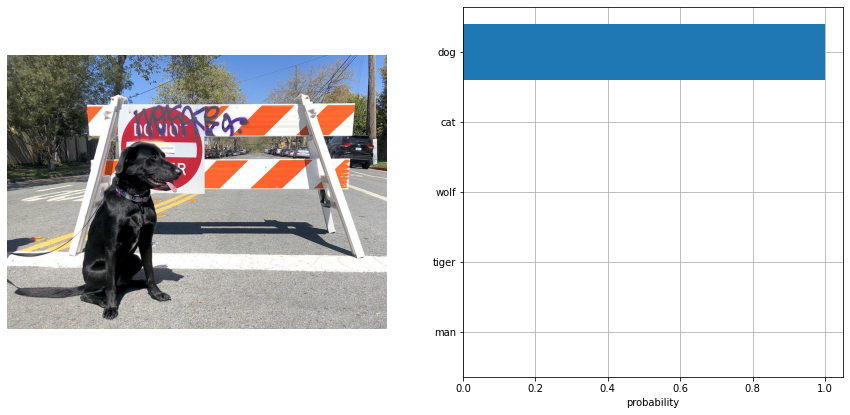

In [20]:
%%skip not $to_quantize.value

compiled_text_model = core.compile_model(int8_text_model_path, device.value)
compiled_vision_model = core.compile_model(int8_vision_model_path, device.value)

text = ov_tokenizer(text=text_descriptions, padding="max_length", max_length=ov_tokenizer.model_max_length, truncation=True, return_tensors='pt')
text_features = text_model(text['input_ids'])[0]

img_data = ov_processor(images=coco_image)['pixel_values']
image_features = visual_model(img_data)[0]

probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
visualize_result(coco_image, input_labels, probs[0])

Nice! Results looks similar to fp16 model results before quantization.

### Compare File Size
[back to top ⬆️](#Table-of-contents:)

In [21]:
%%skip not $to_quantize.value

from pathlib import Path

fp16_ir_model_size = fp16_text_model_path.with_suffix(".bin").stat().st_size / 1024 / 1024
quantized_model_size = int8_text_model_path.with_suffix(".bin").stat().st_size / 1024 / 1024
print(f"FP16 IR text model size: {fp16_ir_model_size:.2f} MB")
print(f"INT8 text model size: {quantized_model_size:.2f} MB")
print(f"Model compression rate: {fp16_ir_model_size / quantized_model_size:.3f}")
print()
fp16_ir_model_size = fp16_vision_model_path.with_suffix(".bin").stat().st_size / 1024 / 1024
quantized_model_size = int8_vision_model_path.with_suffix(".bin").stat().st_size / 1024 / 1024
print(f"FP16 IR vision model size: {fp16_ir_model_size:.2f} MB")
print(f"INT8 vision model size: {quantized_model_size:.2f} MB")
print(f"Model compression rate: {fp16_ir_model_size / quantized_model_size:.3f}")

FP16 IR text model size: 241.98 MB
INT8 text model size: 61.42 MB
Model compression rate: 3.939

FP16 IR vision model size: 335.12 MB
INT8 vision model size: 84.81 MB
Model compression rate: 3.951


### Compare inference time of the FP16 IR and quantized models
[back to top ⬆️](#Table-of-contents:)
To measure the inference performance of the `FP16` and `INT8` models, we use median inference time on calibration dataset.
So we can approximately estimate the speed up of the dynamic quantized models.


> **NOTE**: For the most accurate performance estimation, it is recommended to run `benchmark_app` in a terminal/command prompt after closing other applications with static shapes.

In [22]:
%%skip not $to_quantize.value

import time

def calculate_inference_time(model_path, calibration_data):
    model = core.compile_model(model_path, device.value)
    inference_time = []
    for bratch in calibration_data:
        start = time.perf_counter()
        _ = model(bratch)[0]
        end = time.perf_counter()
        delta = end - start
        inference_time.append(delta)
    return np.median(inference_time)

In [23]:
%%skip not $to_quantize.value

fp16_latency = calculate_inference_time(fp16_text_model_path, calibration_text_data)
int8_latency = calculate_inference_time(int8_text_model_path, calibration_text_data)
print(f"Performance speed up for text model: {fp16_latency / int8_latency:.3f}")

fp16_latency = calculate_inference_time(fp16_vision_model_path, calibration_image_data)
int8_latency = calculate_inference_time(int8_vision_model_path, calibration_image_data)
print(f"Performance speed up for vision model: {fp16_latency / int8_latency:.3f}")

Performance speed up for text model: 1.357
Performance speed up for vision model: 2.245


## Interactive demo
[back to top ⬆️](#Table-of-contents:)

Now, it is your turn! You can provide your own image and comma-separated list of labels for zero-shot classification.

Feel free to upload an image, using the file upload window and type label names into the text field, using comma as the separator (for example, `cat,dog,bird`)

In [24]:
text_model_path = Path("quantized", "openvino_model_text_int8.xml")
vision_model_path = Path("quantized", "openvino_model_vision_int8.xml")
if not text_model_path.exists() or not vision_model_path.exists():
    text_model_path = Path("CLIP-ViT-B-32-laion2B-s34B-b79K", "openvino_model_text.xml")
    vision_model_path = Path("CLIP-ViT-B-32-laion2B-s34B-b79K", "openvino_model_vision.xml")
text_compiled_model = core.compile_model(text_model_path, device.value)
vision_compiled_model = core.compile_model(vision_model_path, device.value)


def classify(image, text):
    """Classify image using classes listing.
    Args:
        image (np.ndarray): image that needs to be classified in CHW format.
        text (str): comma-separated list of class labels
    Returns:
        (dict): Mapping between class labels and class probabilities.
    """
    labels = text.split(",")
    text_descriptions = [f"This is a photo of a {label}" for label in labels]

    text = ov_tokenizer(text=text_descriptions, padding="max_length", max_length=ov_tokenizer.model_max_length, truncation=True, return_tensors="pt")
    text_features = text_compiled_model(text["input_ids"])[0]
    img = torch.Tensor(ov_processor(images=image)["pixel_values"])
    image_features = vision_compiled_model(img)[0]

    probs = torch.Tensor(100.0 * image_features @ text_features.T).softmax(dim=-1)

    return {label: float(prob) for label, prob in zip(labels, probs[0])}

In [ ]:
if not Path("gradio_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/clip-zero-shot-image-classification/gradio_helper.py"
    )
    open("gradio_helper.py", "w").write(r.text)

from gradio_helper import make_demo

demo = make_demo(classify)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(share=True, debug=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/